# Add necessary folders to colab

In [ ]:
!rm -rf /content/sample_data
!git clone https://github.com/MoritzCermann/semantic-segmentation-camvid.git

# move files into /content
!mv /content/semantic-segmentation-camvid/* /content/
!rm -rf /content/semantic-segmentation-camvid

Cloning into 'semantic-segmentation-camvid'...
remote: Enumerating objects: 1439, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 1439 (delta 7), reused 26 (delta 7), pack-reused 1413
Receiving objects: 100% (1439/1439), 570.60 MiB | 17.52 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Updating files: 100% (1410/1410), done.


In [ ]:
!pip install tf2onnx
!pip install tensorflow==2.15 # ERROR in latest tf version (2.17) with 2DTranspose!!??

import tensorflow as tf
import tf2onnx
import onnx

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.0
    Uninstalling ml-dtypes-0.4.0:
      Successfully uninstalled ml-dtypes-0.4.0
  Attempting uninstall: keras
    Found existing installatio

In [ ]:
# These are the only 2 parameter to adjust, depending on the model

model_name = 'unet_miniv2'
input_shape = 256 # height & width

# Convert model to ONNX file format

In [ ]:
path = '/content/drive/MyDrive/ColabNotebooks/' + model_name
model_path = path + '.h5'
output_path = path + '.onnx'

# Download from drive
model = tf.keras.models.load_model(model_path)

input_signature = [tf.TensorSpec([None, input_shape, input_shape, 3], tf.float32, name='input')]

# Convert
model_proto, external_tensor_storage = tf2onnx.convert.from_keras(model, input_signature=input_signature, output_path=output_path, opset = 13)

# Upload to drive - NOT needed, already directly saving model to drive
#!cp {output_path} {output_path}

# Testing the model with ONNX Runtime --- NOT USED IN THIS WORK CAN BE IGNORED

In [ ]:
!pip install onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 46.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.3 MB/s eta 0:00:00


In [ ]:
import onnxruntime as ort
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

sess = ort.InferenceSession(output_path)
input_name = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

img_path = '/content/data/CamVid_RGB/0016E5_07975.png'
input_size = (input_shape, input_shape)  # input_shape defined above
img = load_img(img_path, target_size=input_size)
img_array = img_to_array(img)


img_array = img_array / 255.0

# Hinzufügen der Batch-Dimension
img_array = np.expand_dims(img_array, axis=0)

# Run inference
outputs = sess.run([output_name], {input_name: img_array.astype(np.float32)})[0]


predicted_mask = np.argmax(outputs, axis=-1)
predicted_mask = np.expand_dims(predicted_mask, axis=-1)

# Plot an image with predicted mask

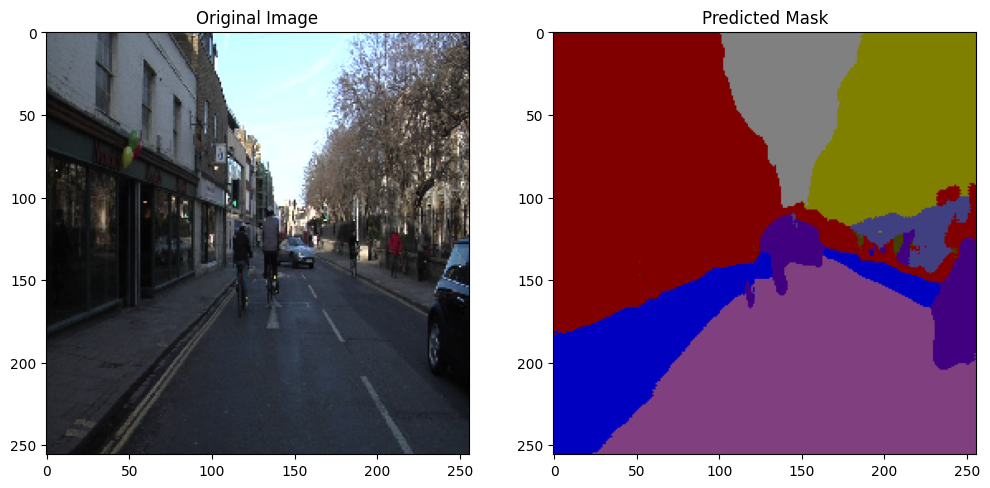

In [ ]:
import matplotlib.pyplot as plt
from utils import convert_indexed_to_rgb_mask

predicted_mask = np.squeeze(predicted_mask)
if predicted_mask.ndim == 3:
    predicted_mask = predicted_mask[:, :, 0]  # Annahme, dass die Maske eine zusätzliche Dimension hat, die entfernt werden muss

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(np.squeeze(img_array), vmin=0, vmax=1)
ax[0].set_title('Original Image')
ax[1].imshow(convert_indexed_to_rgb_mask_new(predicted_mask), vmin=0, vmax=1)
ax[1].set_title('Predicted Mask')

plt.show()

In [ ]:
def convert_indexed_to_rgb_mask_new(mask):
    '''
    Convert a single indexed masks to RGB masks using the colormap of the original paper.
    '''
    color_dict = {
        0: (128, 128, 128),  # Sky
        1: (128, 0, 0),      # Building
        2: (192, 192, 128),  # Pole
        3: (128, 64, 128),   # Road
        4: (0, 0, 192),      # Sidewalk
        5: (128, 128, 0),    # Tree
        6: (192, 128, 128),  # SignSymbol
        7: (64, 64, 128),    # Fence
        8: (64, 0, 128),     # Car
        9: (64, 64, 0),      # Pedestrian
        10: (0, 128, 192),   # Bicyclist
        255: (0, 0, 0)       # Void
    }
    mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)

    for i in range(11):
        if i in color_dict:
            mask_rgb[mask == i] = color_dict[i]

    return mask_rgb